### Anomaly Detection Using Auto Encoder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import seaborn as sns
import joblib

In [3]:
#load the dataset
df=pd.read_csv('sensor_data_5000_with_timestamp.csv')
df.head()

,timestamp,temperature,pressure,vibration,humidity
0,2026-01-01 00:00:00,70.993428,29.576240,0.466075,39.569730
1,2026-01-01 00:00:01,69.723471,29.546586,0.484725,39.902032
2,2026-01-01 00:00:02,71.295377,28.204357,0.470131,40.192885
3,2026-01-01 00:00:03,73.046060,29.669910,0.505521,42.840584
4,2026-01-01 00:00:04,69.531693,30.732829,0.559859,37.758348


In [4]:
#checking the missing data null and  Show shape and basic stats
print("------------------------------------------")
print(" Null value checking")
print(df.isnull().sum())
print("Shape of the dataset")
print(df.shape)
print("find the count mean standard deviation and minimum , percentile and maximum value")
print(df.describe())

------------------------------------------
 Null value checking
timestamp      0
temperature    0
pressure       0
vibration      0
humidity       0
dtype: int64
Shape of the dataset
(5000, 5)
find the count mean standard deviation and minimum , percentile and maximum value
       temperature     pressure    vibration     humidity
count  5000.000000  5000.000000  5000.000000  5000.000000
mean     70.892907    30.489283     0.535754    41.246056
std       4.181479     2.349689     0.153323     5.649695
min      63.517465    26.077600     0.331221    28.430874
25%      68.783878    29.366648     0.469393    38.179887
50%      70.196051    30.063308     0.504822    40.291190
75%      71.646396    30.833163     0.542353    42.622384
max      99.066561    47.844195     1.524364    73.864623


In [5]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by timestamp
df = df.sort_values('timestamp')
print(df.head())

            timestamp  temperature   pressure  vibration   humidity
0 2026-01-01 00:00:00    70.993428  29.576240   0.466075  39.569730
1 2026-01-01 00:00:01    69.723471  29.546586   0.484725  39.902032
2 2026-01-01 00:00:02    71.295377  28.204357   0.470131  40.192885
3 2026-01-01 00:00:03    73.046060  29.669910   0.505521  42.840584
4 2026-01-01 00:00:04    69.531693  30.732829   0.559859  37.758348


In [6]:
# Simulate anomalies if not present
if 'anomaly' not in df.columns:
    np.random.seed(42)
    df['anomaly'] = 0
    anomaly_indices = np.random.choice(df.index, 50, replace=False)
    df.loc[anomaly_indices, 'anomaly'] = 1

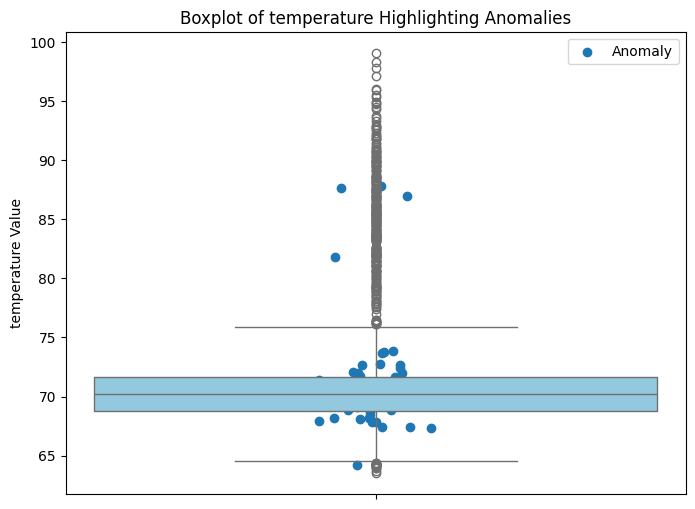

In [7]:
# Pick sensor column
sensor_col = 'temperature'  # change to your sensor column

# Create figure
plt.figure(figsize=(8,6))

# Base boxplot for all data
sns.boxplot(y=df[sensor_col], color='skyblue')

# Overlay anomalies as red points
anomalies = df[df['anomaly'] == 1]
plt.scatter(
    x=np.random.normal(0, 0.04, size=len(anomalies)),  # jitter x for visibility
    y=anomalies[sensor_col],
    label='Anomaly'
)

plt.title(f'Boxplot of {sensor_col} Highlighting Anomalies')
plt.ylabel(f'{sensor_col} Value')
plt.legend()
plt.show()

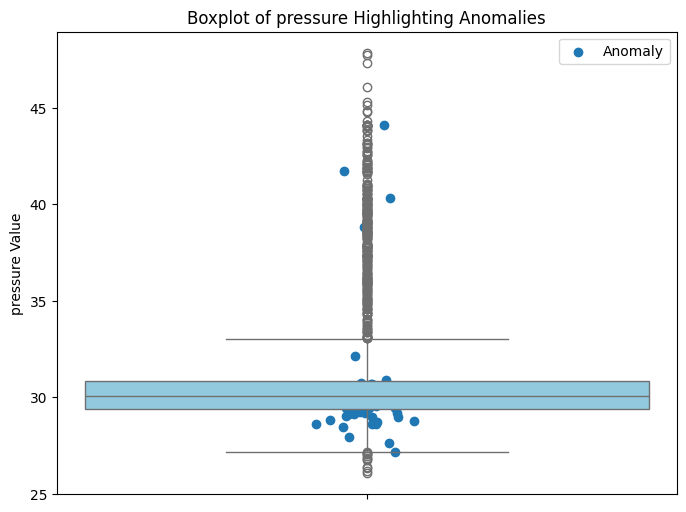

In [8]:
# Pick sensor column
sensor_col = 'pressure'  # change to your sensor column

# Create figure
plt.figure(figsize=(8,6))

# Base boxplot for all data
sns.boxplot(y=df[sensor_col], color='skyblue')

# Overlay anomalies as red points
anomalies = df[df['anomaly'] == 1]
plt.scatter(
    x=np.random.normal(0, 0.04, size=len(anomalies)),  # jitter x for visibility
    y=anomalies[sensor_col],
    label='Anomaly'
)

plt.title(f'Boxplot of {sensor_col} Highlighting Anomalies')
plt.ylabel(f'{sensor_col} Value')
plt.legend()
plt.show()

In [9]:
 #2Define features for modeling
# --------------------------
# Drop columns that are NOT features (labels or timestamps)
feature_cols = [col for col in df.columns if col not in ["timestamp", "anomaly", "anomaly_str"]]

X = df[feature_cols]

# --------------------------
# 3️⃣ Scale features
# --------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, "scaler.pkl")
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (5000, 4)


In [14]:

# --------------------------
# 4️⃣ Build Autoencoder
# --------------------------
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)
decoded = Dense(16, activation="relu")(encoded)
output_layer = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer="adam", loss="mse")

# --------------------------
# 5️⃣ Train Autoencoder
# --------------------------
autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

# --------------------------
# 6️⃣ Save Autoencoder
# --------------------------
autoencoder.save("autoencoder.keras")

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0514 - val_loss: 0.0175
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0157 - val_loss: 0.0081
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0070 - val_loss: 0.0042
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0027
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - val_loss: 0.0026
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 9/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - val_loss: 0.0024
Epoch 10/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 11/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 12/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [11]:
# After training
reconstructions = autoencoder.predict(X_scaled)
losses = np.mean(np.square(reconstructions - X_scaled), axis=1)

# Choose threshold
threshold = np.mean(losses) + 2 * np.std(losses)

# Flag anomalies
df["anomaly"] = losses > threshold

print("Anomaly threshold set at:", threshold)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Anomaly threshold set at: 0.0007275465721188738


In [12]:
print(df['anomaly'].value_counts())


anomaly
False    4877
True      123
Name: count, dtype: int64
